# 3 · Coupled PDEs without writing a Jacobian: current distribution in a porous electrode

Battery and fuel-cell electrodes are **porous**: an electronically conducting solid matrix is filled with electrolyte, and the electrochemical reaction takes place on the huge internal surface where the two phases meet. How deep into the electrode does the reaction reach? The classic answer comes from Newman & Tobias (1962) and *Electrochemical Systems*, ch. 22.

This notebook:

1. sets up the two coupled equations for the potentials in the solid and the electrolyte, linked by **Butler–Volmer** kinetics;
2. solves them **from the residual alone** with `bs.newton_fd`, with no Jacobian written;
3. validates against the analytic solution for linear kinetics, and confirms second-order accuracy;
4. explores the nonlinear regime and the controlling dimensionless group;
5. shows the optional next step: a hand-written Jacobian, verified with `bs.check_jacobian`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bandsolver as bs

# Plot style: categorical colours in fixed order, an ordinal blue ramp for time series,
# neutral ink for text, thin marks and a recessive grid.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
RAMP = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]   # light -> dark
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "lines.markersize": 6, "legend.frameon": False,
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11,
})
print("bandsolver", bs.__version__, "| backends:", bs.BACKENDS)

bandsolver 0.1.0 | backends: ('cpp', 'fortran')


## 1. Model

Take a one-dimensional electrode of thickness $L$. The separator is at $x=0$, where ionic current enters, and the current collector is at $x=L$, where electronic current leaves. Assume the electrolyte concentration is uniform, so there is no concentration polarization, and write:

| quantity | solid matrix (phase 1) | electrolyte (phase 2) |
|---|---|---|
| potential | $\phi_1$ | $\phi_2$ |
| current density (Ohm's law) | $i_1 = -\sigma\,\dfrac{d\phi_1}{dx}$ | $i_2 = -\kappa\,\dfrac{d\phi_2}{dx}$ |

The total current is conserved, $i_1 + i_2 = I$. Charge moves from one phase to the other only through the reaction, which has a rate $j$ per unit interfacial area and an interfacial area $a$ per unit volume:

$$
\frac{di_2}{dx} = a\,j, \qquad \frac{di_1}{dx} = -a\,j, \qquad
j = i_0\left[\exp\!\left(\frac{\alpha_a F}{RT}\eta\right) - \exp\!\left(-\frac{\alpha_c F}{RT}\eta\right)\right], \qquad
\eta = \phi_1 - \phi_2 .
$$

Here $\eta$ is the local overpotential, measured relative to the equilibrium potential. Substituting Ohm's law gives **two coupled, nonlinear second-order ODEs**:

$$
\boxed{\;\sigma\,\frac{d^2\phi_1}{dx^2} = a\,j(\phi_1-\phi_2), \qquad \kappa\,\frac{d^2\phi_2}{dx^2} = -a\,j(\phi_1-\phi_2)\;}
$$

**Boundary conditions:**

$$
\begin{aligned}
&x = 0\ (\text{separator}): && i_1 = 0, \quad i_2 = I, \\
&x = L\ (\text{current collector}): && i_2 = 0, \quad \phi_1 = 0 \ \ (\text{reference}).
\end{aligned}
$$

As in the previous notebook, only potential *differences* matter, so a reference is needed. The remaining condition $i_1(L) = I$ follows from conservation. For $I>0$, current passes from the electrolyte into the solid, so the reaction is cathodic ($j<0$, $\eta<0$), as in a battery cathode during discharge.

### Analytic solution for linear kinetics

At small overpotential, $j \approx i_0\,(\alpha_a+\alpha_c)\,\frac{F}{RT}\,\eta$. Subtracting the two equations then gives a single linear equation for $\eta$:

$$
\frac{d^2\eta}{dx^2} = k^2\,\eta,\qquad k^2 = a\,i_0\,(\alpha_a+\alpha_c)\,\frac{F}{RT}\left(\frac1\sigma + \frac1\kappa\right),
\qquad \frac{d\eta}{dx}\Big|_0 = \frac{I}{\kappa},\quad \frac{d\eta}{dx}\Big|_L = -\frac{I}{\sigma},
$$

whose solution is

$$
\eta(x) = \mathcal A\cosh kx + \mathcal B\sinh kx,\qquad \mathcal B = \frac{I}{\kappa k},\qquad
\mathcal A = -\frac{I/(\sigma k) + \mathcal B\cosh kL}{\sinh kL}.
$$

The dimensionless group $\nu = kL$ controls the shape. For $\nu \ll 1$ the reaction is spread uniformly through the electrode. For $\nu \gg 1$ it is squeezed into thin layers of thickness about $L/\nu$ at the two faces. The boundary slopes $\eta'(0) = I/\kappa$ and $\eta'(L) = -I/\sigma$ make the peak at the separator larger than the one at the current collector by roughly $\sigma/\kappa$.

In [2]:
F, R, T = 96485.33212, 8.314462618, 298.15
f = F / (R * T)                                   # 1/V
L = 100e-6                                        # electrode thickness, m
sigma, kappa = 10.0, 1.0                          # solid / electrolyte conductivity, S/m
a = 1.0e6                                         # interfacial area per volume, 1/m
i0 = 1.0                                          # exchange current density, A/m^2
alpha_a = alpha_c = 0.5

def kinetics(eta, i0=i0, linear=False):
    """Reaction rate j(eta) in A/m^2 of interface."""
    if linear:
        return i0 * (alpha_a + alpha_c) * f * eta
    return i0 * (np.exp(alpha_a * f * eta) - np.exp(-alpha_c * f * eta))

def nu(i0=i0):
    return L * np.sqrt(a * i0 * (alpha_a + alpha_c) * f * (1 / sigma + 1 / kappa))

def eta_analytic(x, I, i0=i0):
    k = nu(i0) / L
    Bc = I / (kappa * k)
    Ac = -(I / (sigma * k) + Bc * np.cosh(k * L)) / np.sinh(k * L)
    return Ac * np.cosh(k * x) + Bc * np.sinh(k * x)

print(f"nu = kL = {nu():.3f}")

nu = kL = 0.654


## 2. Discretization: just the residual

We use node-centred control volumes as in notebook 2, with face currents $i_{1,j+\frac12} = -\sigma(\phi_{1,j+1}-\phi_{1,j})/h$ (and likewise for $i_2$). Integrating the two current balances over control volume $j$ gives

$$
\begin{aligned}
F_{1,j} &= i_{1,\,j+\frac12} - i_{1,\,j-\frac12} + a\,j_j\,V_j = 0 &&(\text{solid}),\\
F_{2,j} &= i_{2,\,j+\frac12} - i_{2,\,j-\frac12} - a\,j_j\,V_j = 0 &&(\text{electrolyte}),
\end{aligned}
$$

with $V_j = h$ inside and $h/2$ in the two boundary volumes. At the walls the outer face currents are the boundary values: $i_1 = 0$ and $i_2 = I$ at $x=0$, and $i_2 = 0$ at $x=L$. The solid balance at the last node is replaced by the reference condition $\phi_{1}(L) = 0$.

Each node has $n=2$ unknowns, $(\phi_1,\phi_2)$. We only write $\mathbf F$; `bs.newton_fd` builds the $2\times2$ blocks by finite differences, at a cost of $3n+1 = 7$ residual evaluations per Newton iteration.

In [3]:
def make_residual(I, nj, i0=i0, linear=False):
    h = L / (nj - 1)
    V = np.full(nj, h); V[0] = V[-1] = h / 2

    def residual(u):
        phi1, phi2 = u[:, 0], u[:, 1]
        rxn = a * kinetics(phi1 - phi2, i0, linear) * V      # a j V, per control volume
        i1 = -sigma * np.diff(phi1) / h                      # face currents
        i2 = -kappa * np.diff(phi2) / h
        Fr = np.zeros((nj, 2))
        Fr[:, 0] = rxn;  Fr[:-1, 0] += i1;  Fr[1:, 0] -= i1  # solid balance
        Fr[:, 1] = -rxn; Fr[:-1, 1] += i2;  Fr[1:, 1] -= i2  # electrolyte balance
        Fr[0, 0] -= 0.0                                       # i1 = 0 enters at x = 0
        Fr[0, 1] -= I                                         # i2 = I enters at x = 0
        Fr[-1, 1] += 0.0                                      # i2 = 0 leaves at x = L
        Fr[-1, 0] = phi1[-1]                                  # reference phi1(L) = 0
        return Fr
    return residual

I = 10.0                                                      # A/m^2: small, nearly linear regime
nj = 101
x = np.linspace(0, L, nj)
res = bs.newton_fd(make_residual(I, nj, linear=True), np.zeros((nj, 2)))
eta = res.c[:, 0] - res.c[:, 1]
print(f"linear kinetics: {res.iterations} Newton iterations, {res.residual_evaluations} residual calls")
print(f"max |eta - analytic| / max|eta| = {np.abs(eta - eta_analytic(x, I)).max() / np.abs(eta).max():.1e}")
h = L / (nj - 1); V = np.full(nj, h); V[0] = V[-1] = h / 2
print(f"total reaction  sum(a j V) = {np.sum(a * kinetics(eta, linear=True) * V):.6f} A/m^2  (should be -I = {-I})")

linear kinetics: 2 Newton iterations, 14 residual calls
max |eta - analytic| / max|eta| = 3.9e-06
total reaction  sum(a j V) = -10.000000 A/m^2  (should be -I = -10.0)


The linear problem converges at iteration 2: the first correction is exact, and the second confirms it. The total reaction exactly balances the applied current, as the conservative discretization guarantees.

A refinement study confirms the expected second-order accuracy against the analytic $\eta(x)$:

In [4]:
grids = [21, 41, 81, 161, 321]
errs = []
for m in grids:
    xm = np.linspace(0, L, m)
    r = bs.newton_fd(make_residual(I, m, linear=True), np.zeros((m, 2)))
    errs.append(np.abs((r.c[:, 0] - r.c[:, 1]) - eta_analytic(xm, I)).max())
for m, e, o in zip(grids, errs, [np.nan] + list(np.log2(np.array(errs[:-1]) / np.array(errs[1:])))):
    print(f"nj = {m:4d}   max |eta - analytic| = {e:.3e} V   observed order {o:.3f}")

nj =   21   max |eta - analytic| = 2.834e-07 V   observed order nan
nj =   41   max |eta - analytic| = 7.086e-08 V   observed order 2.000
nj =   81   max |eta - analytic| = 1.772e-08 V   observed order 2.000
nj =  161   max |eta - analytic| = 4.429e-09 V   observed order 2.000
nj =  321   max |eta - analytic| = 1.107e-09 V   observed order 2.000


## 3. Butler–Volmer kinetics: the nonlinear regime

At larger currents the overpotential exceeds $RT/F \approx 26$ mV. The exponential kinetics then make the problem strongly nonlinear, and the reaction concentrates where the overpotential is largest. The residual is identical except that `linear=False`. Newton's method, starting from $\phi_1=\phi_2=0$, handles it in a few more iterations.

We plot the normalized reaction distribution, $-a\,j\,L/I$, which averages to 1 over the electrode.

I =     10 A/m^2: 3 Newton iterations; eta from    -2.9 mV (x=0) to    -2.4 mV (x=L); reaction ratio x=0 / x=L = 1.18
I =    100 A/m^2: 5 Newton iterations; eta from   -27.8 mV (x=0) to   -23.5 mV (x=L); reaction ratio x=0 / x=L = 1.20
I =   1000 A/m^2: 9 Newton iterations; eta from  -145.3 mV (x=0) to  -107.3 mV (x=L); reaction ratio x=0 / x=L = 2.12


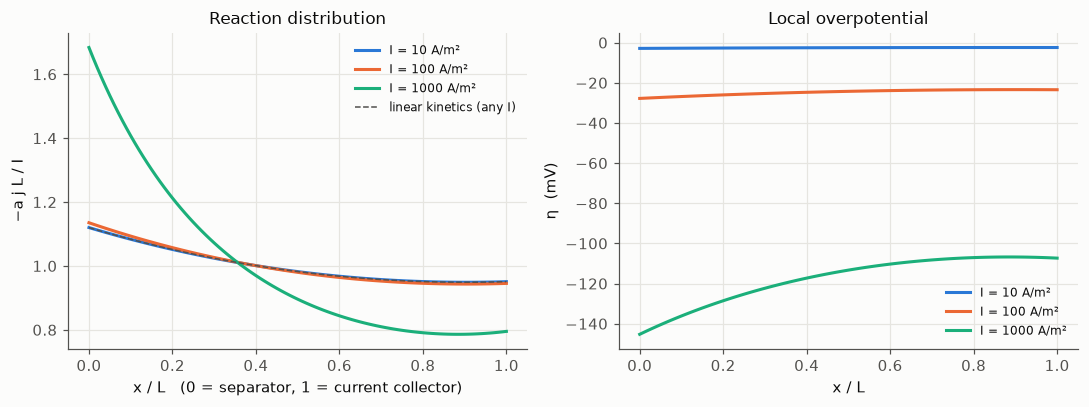

In [5]:
currents = [10.0, 100.0, 1000.0]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
for I_k, color in zip(currents, [BLUE, ORANGE, AQUA]):
    r = bs.newton_fd(make_residual(I_k, nj), np.zeros((nj, 2)))
    eta_k = r.c[:, 0] - r.c[:, 1]
    dist = -a * kinetics(eta_k) * L / I_k
    print(f"I = {I_k:6.0f} A/m^2: {r.iterations} Newton iterations; eta from {eta_k[0]*1e3:7.1f} mV (x=0) "
          f"to {eta_k[-1]*1e3:7.1f} mV (x=L); reaction ratio x=0 / x=L = {dist[0] / dist[-1]:.2f}")
    ax1.plot(x / L, dist, color=color, label=f"I = {I_k:g} A/m²")
    ax2.plot(x / L, eta_k * 1e3, color=color, label=f"I = {I_k:g} A/m²")
r_lin = bs.newton_fd(make_residual(1000.0, nj, linear=True), np.zeros((nj, 2)))
ax1.plot(x / L, -a * kinetics(r_lin.c[:, 0] - r_lin.c[:, 1], linear=True) * L / 1000.0,
         color=INK2, linewidth=1, linestyle="--", label="linear kinetics (any I)")
ax1.set_xlabel("x / L   (0 = separator, 1 = current collector)"); ax1.set_ylabel("−a j L / I")
ax1.set_title("Reaction distribution"); ax1.legend(fontsize=8)
ax2.set_xlabel("x / L"); ax2.set_ylabel("η  (mV)"); ax2.set_title("Local overpotential"); ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

With linear kinetics the *shape* of the distribution does not depend on $I$ (the dashed line). With Butler–Volmer kinetics, higher currents drive the reaction toward the separator, because there the electrolyte, the poorer conductor ($\kappa < \sigma$), has the shortest path. At low current the Butler–Volmer and linear results coincide, as they should.

## 4. The controlling parameter $\nu = kL$

Varying the exchange current density $i_0$ changes $\nu$. We keep the current small so the kinetics stay linear, which isolates the geometric effect.

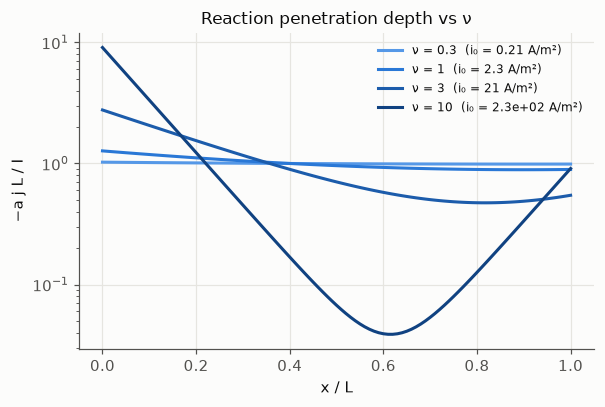

In [6]:
fig, ax = plt.subplots(figsize=(5.6, 3.8))
for nu_target, color in zip([0.3, 1.0, 3.0, 10.0], RAMP[1:]):
    i0_k = (nu_target / L)**2 / (a * (alpha_a + alpha_c) * f * (1 / sigma + 1 / kappa))
    r = bs.newton_fd(make_residual(0.1, nj, i0=i0_k), np.zeros((nj, 2)))
    dist = -a * kinetics(r.c[:, 0] - r.c[:, 1], i0=i0_k) * L / 0.1
    ax.plot(x / L, dist, color=color, label=f"ν = {nu_target:g}  (i₀ = {i0_k:.2g} A/m²)")
ax.set_xlabel("x / L"); ax.set_ylabel("−a j L / I"); ax.set_yscale("log")
ax.set_title("Reaction penetration depth vs ν"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

For $\nu = 0.3$ the whole electrode is used almost uniformly. For $\nu = 10$ the reaction is confined to thin layers at the two faces, and the middle of the electrode sits nearly idle. The layer at the separator is about $\sigma/\kappa = 10$ times more intense than the one at the current collector (read the two ends of the darkest curve), because the electrolyte is the poorer conductor. That is the design trade-off behind electrode thickness and conductivity choices.

## 5. Optional: a hand-written Jacobian, checked

`newton_fd` is convenient and robust. A hand-written Jacobian avoids the $3n+1$ residual calls per iteration, which matters when the residual is expensive. The derivatives here are simple:

$$
\frac{\partial (a\,j\,V_j)}{\partial \phi_{1,j}} = -\frac{\partial (a\,j\,V_j)}{\partial \phi_{2,j}} = a\,V_j\,\frac{dj}{d\eta},
\qquad \frac{dj}{d\eta} = i_0\left[\tfrac{\alpha_a F}{RT}e^{\alpha_a F\eta/RT} + \tfrac{\alpha_c F}{RT}e^{-\alpha_c F\eta/RT}\right],
$$

and each face current contributes $\pm\sigma/h$ or $\pm\kappa/h$ to the neighbouring blocks. We write the fill, check it, and compare the cost.

In [7]:
def make_fill(I, nj):
    h = L / (nj - 1)
    V = np.full(nj, h); V[0] = V[-1] = h / 2
    residual = make_residual(I, nj)

    def fill(u):
        eta = u[:, 0] - u[:, 1]
        djde = i0 * (alpha_a * f * np.exp(alpha_a * f * eta) + alpha_c * f * np.exp(-alpha_c * f * eta))
        g = a * V * djde                                     # d(a j V)/d eta
        A = np.zeros((nj, 2, 2)); B = np.zeros((nj, 2, 2)); D = np.zeros((nj, 2, 2))
        for row, (cond, sign) in enumerate([(sigma, +1), (kappa, -1)]):
            # conduction: F_j = -cond (p_{j+1} - p_j)/h + cond (p_j - p_{j-1})/h  (+/- reaction)
            B[:-1, row, row] += cond / h;  D[:-1, row, row] = -cond / h
            B[1:, row, row] += cond / h;   A[1:, row, row] = -cond / h
            B[:, row, 0] += sign * g;      B[:, row, 1] -= sign * g
        A[-1, 0, :] = 0; B[-1, 0, :] = [1.0, 0.0]            # reference row phi1(L) = 0
        return A, B, D, -residual(u)
    return fill

I = 1000.0
u_test = np.column_stack([np.linspace(-0.05, 0.0, nj), np.linspace(0.12, 0.10, nj)])
print(f"check_jacobian score = {bs.check_jacobian(make_fill(I, nj), u_test).max_error:.1e}")

import time
for label, run in [("newton (hand-written)", lambda: bs.newton(make_fill(I, nj), np.zeros((nj, 2)))),
                   ("newton_fd (residual only)", lambda: bs.newton_fd(make_residual(I, nj), np.zeros((nj, 2))))]:
    t0 = time.perf_counter(); r = run(); dt_ms = (time.perf_counter() - t0) * 1e3
    calls = r.residual_evaluations or r.iterations
    print(f"{label:27s} {r.iterations} iterations, {calls:3d} residual/fill calls, {dt_ms:6.2f} ms")

check_jacobian score = 4.0e-08
newton (hand-written)       9 iterations,   9 residual/fill calls,   0.49 ms
newton_fd (residual only)   9 iterations,  63 residual/fill calls,   1.15 ms


Both routes converge in the same number of iterations to the same solution. The finite-difference route costs $3n+1 = 7$ residual calls per iteration instead of one fill call. For cheap residuals like this one the difference is milliseconds; for expensive property models, a verified hand-written Jacobian pays off.

## Takeaways

- **Two coupled nonlinear equations with a reference condition** map directly onto BAND. You only need to write the residual.
- `bs.newton_fd` makes prototyping fast. When performance matters, write the Jacobian and verify it with `bs.check_jacobian`.
- The workflow is the same as for any model: **validate against an analytic limit** (here linear kinetics, $O(h^2)$) before trusting the nonlinear results.

**Try it:** add a third unknown, the electrolyte concentration, with its own diffusion equation and a concentration-dependent $i_0$ and $\kappa$. This moves toward the full Newman porous-electrode model. With `newton_fd`, only the residual changes.